SETTAGGIO AMBIENTE

In [86]:
import os
import pandas as pd
import unicodedata
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

IMPORT DEI DATI

In [87]:
decessi_2015 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2015.xlsx')
decessi_2016 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2016.xlsx')
decessi_2017 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2017.xlsx')
decessi_2018 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2018.xlsx')
decessi_2019 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2019.xlsx')
decessi_2020 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2020.xlsx')
decessi_2021 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2021.xlsx')
decessi_2022 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2022.xlsx')
decessi_2023 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2023.xlsx')
decessi_2024 = pd.read_excel(r'C:\Users\maria\Desktop\portfolio_mortalità\data\raw\tabella provinciale decessi definitivi_classe_età_2024.xlsx')

PULITURA DATI

In [88]:
# MASCHI | 0-49 ANNI	50-64 ANNI	65-79 ANNI	80 ANNI E PIU' | FEMMINE |	0-49 ANNI	50-64 ANNI	65-79 ANNI	80 ANNI E PIU'
# Si rende necessario implementare una funzione per la rinomina delle colonne, dopo averne comunque confermato l'omogeneità nei vari file importati

def rinomina_colonne_decessi(df):
    mesi = [
        "gennaio", "febbraio", "marzo", "aprile",
        "maggio", "giugno", "luglio", "agosto",
        "settembre", "ottobre", "novembre", "dicembre"
    ]

    nuove_colonne = ["id_provincia", "provincia"]

    for mese in mesi:
        nuove_colonne.extend([
            f"maschi_0_49_{mese}",
            f"maschi_50_64_{mese}",
            f"maschi_65_79_{mese}",
            f"maschi_80_plus_{mese}",
            f"femmine_0_49_{mese}",
            f"femmine_50_64_{mese}",
            f"femmine_65_79_{mese}",
            f"femmine_80_plus_{mese}",
        ])

    if len(df.columns) != len(nuove_colonne):
        raise ValueError(
            f"Il dataframe ha {len(df.columns)} colonne, "
            f"ma ne attendevo {len(nuove_colonne)}."
        )

    df = df.copy()
    df.columns = nuove_colonne
    df = df.drop(df.index[[0,1]]).reset_index(drop=True)
    return df

decessi_2015 = rinomina_colonne_decessi(decessi_2015)
decessi_2016 = rinomina_colonne_decessi(decessi_2016)
decessi_2017 = rinomina_colonne_decessi(decessi_2017)
decessi_2018 = rinomina_colonne_decessi(decessi_2018)
decessi_2019 = rinomina_colonne_decessi(decessi_2019)
decessi_2020 = rinomina_colonne_decessi(decessi_2020)
decessi_2021 = rinomina_colonne_decessi(decessi_2021)
decessi_2022 = rinomina_colonne_decessi(decessi_2022)
decessi_2023 = rinomina_colonne_decessi(decessi_2023)
decessi_2024 = rinomina_colonne_decessi(decessi_2024)

print("Aggiornate intestazioni colonne\n")

Aggiornate intestazioni colonne



ACCORPAMENTO DELLE PROVINCE IN MACROAREE NORD / CENTRO / SUD / ISOLE

In [89]:
macroaree = {
    "nord": [
        "Novara", "Cuneo", "Asti", "Alessandria",
        "Valle d'Aosta/Vallée d'Aoste",
        "Imperia", "Savona", "Genova", "La Spezia",
        "Varese", "Como", "Sondrio", "Milano", "Bergamo", "Brescia",
        "Pavia", "Cremona", "Mantova",
        "Bolzano/Bozen", "Trento",
        "Verona", "Vicenza", "Belluno", "Treviso", "Venezia", "Padova", "Rovigo",
        "Udine", "Gorizia", "Trieste", "Pordenone",
        "Piacenza", "Parma", "Reggio nell'Emilia", "Modena", "Bologna",
        "Ferrara", "Ravenna", "Forlì-Cesena", "Rimini",
        "Lecco", "Lodi", "Monza e della Brianza",
        "Verbano-Cusio-Ossola", "Biella", "Torino", "Vercelli"
    ],

    "centro": [
        "Massa-Carrara", "Lucca", "Pistoia", "Firenze", "Livorno",
        "Pisa", "Arezzo", "Siena", "Grosseto", "Prato",
        "Perugia", "Terni",
        "Pesaro e Urbino", "Ancona", "Macerata", "Ascoli Piceno", "Fermo",
        "Viterbo", "Rieti", "Roma", "Latina", "Frosinone"
    ],

    "sud": [
        "L'Aquila", "Teramo", "Pescara", "Chieti",
        "Campobasso", "Isernia",
        "Caserta", "Benevento", "Napoli", "Avellino", "Salerno",
        "Foggia", "Barletta-Andria-Trani", "Bari", "Taranto", "Brindisi", "Lecce",
        "Potenza", "Matera",
        "Cosenza", "Catanzaro", "Reggio Calabria", "Crotone", "Vibo Valentia"
    ],

    "isole": [
        "Trapani", "Palermo", "Messina", "Agrigento", "Caltanissetta",
        "Enna", "Catania", "Ragusa", "Siracusa",
        "Sassari", "Nuoro", "Oristano", "Cagliari",
        "Sud Sardegna"
    ]
}

dfs = {
    2015: decessi_2015,
    2016: decessi_2016,
    2017: decessi_2017,
    2018: decessi_2018,
    2019: decessi_2019,
    2020: decessi_2020,
    2021: decessi_2021,
    2022: decessi_2022,
    2023: decessi_2023,
    2024: decessi_2024
}

provincia_to_macroarea = {
    prov: macro
    for macro, lista in macroaree.items()
    for prov in lista
}

def pulisci_provincia(x):
    x = str(x)
    x = unicodedata.normalize("NFKC", x)
    x = x.strip()
    x = x.replace("’", "'")
    x = x.replace("\xa0", " ")
    return x

def aggrega_per_macroarea(df):
    df = df.copy()

    df["provincia"] = df["provincia"].apply(pulisci_provincia)

    df["macroarea"] = df["provincia"].map(provincia_to_macroarea)

    for col in df.columns:
        if col not in ["provincia", "macroarea"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    non_mappate = df[df["macroarea"].isna()]["provincia"].unique()
    if len(non_mappate) > 0:
        print("\n!!! Province non mappate:")
        print(non_mappate)

    df_macro = (
        df.groupby("macroarea", as_index=False)
        .sum(numeric_only=True)
    )

    return df_macro

dfs_macro = {
    anno: aggrega_per_macroarea(df)
    for anno, df in dfs.items()
}

for i in range(2015, 2025):
    dfs_macro[i].drop(columns=["id_provincia"], inplace=True)

# Esempio: dfs_macro[2015]

ESPORTAZIONE

In [90]:
cartella_output = r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed"

os.makedirs(cartella_output, exist_ok=True)

for anno, df in dfs_macro.items():
    percorso_file = os.path.join(
        cartella_output,
        f"decessi_macroaree_{anno}.csv"
    )

    df.to_csv(
        percorso_file,
        index=False,
        encoding="utf-8-sig"
    )

print("Esportazione completata.")

Esportazione completata.


CREAZIONE ED ESPORTAZIONE DATASET UNICO PER MACROAREE

In [91]:
df_all = pd.concat(
    [df.assign(anno=anno) for anno, df in dfs_macro.items()],
    ignore_index=True
)

df_all.to_csv(
    r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_2015_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

conn = sqlite3.connect(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_completo.db")
df_all.to_sql("decessi_macroaree", conn, if_exists="replace", index=False)
for anno, df in dfs_macro.items():
    df.to_sql(f"decessi_{anno}", conn, if_exists="replace", index=False)
    print(f"✓ Tabella decessi_{anno} creata")
conn.close()

print("✓ Database SQLite esportato in mortalita.db")

print("Esportazione completata")

✓ Tabella decessi_2015 creata
✓ Tabella decessi_2016 creata
✓ Tabella decessi_2017 creata
✓ Tabella decessi_2018 creata
✓ Tabella decessi_2019 creata
✓ Tabella decessi_2020 creata
✓ Tabella decessi_2021 creata
✓ Tabella decessi_2022 creata
✓ Tabella decessi_2023 creata
✓ Tabella decessi_2024 creata
✓ Database SQLite esportato in mortalita.db
Esportazione completata


SUDDIVISIONE AGGIUNTIVA PER STAGIONALITA'

In [92]:
conn = sqlite3.connect(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_completo.db")

query_stagionale = """
SELECT
    macroarea,
    {anno} AS anno,
    (maschi_0_49_dicembre + maschi_0_49_gennaio + maschi_0_49_febbraio +
     femmine_0_49_dicembre + femmine_0_49_gennaio + femmine_0_49_febbraio) AS inverno_0_49,
    (maschi_50_64_dicembre + maschi_50_64_gennaio + maschi_50_64_febbraio +
     femmine_50_64_dicembre + femmine_50_64_gennaio + femmine_50_64_febbraio) AS inverno_50_64,
    (maschi_65_79_dicembre + maschi_65_79_gennaio + maschi_65_79_febbraio +
     femmine_65_79_dicembre + femmine_65_79_gennaio + femmine_65_79_febbraio) AS inverno_65_79,
    (maschi_80_plus_dicembre + maschi_80_plus_gennaio + maschi_80_plus_febbraio +
     femmine_80_plus_dicembre + femmine_80_plus_gennaio + femmine_80_plus_febbraio) AS inverno_80_plus,
    (maschi_0_49_marzo + maschi_0_49_aprile + maschi_0_49_maggio +
     femmine_0_49_marzo + femmine_0_49_aprile + femmine_0_49_maggio) AS primavera_0_49,
    (maschi_50_64_marzo + maschi_50_64_aprile + maschi_50_64_maggio +
     femmine_50_64_marzo + femmine_50_64_aprile + femmine_50_64_maggio) AS primavera_50_64,
    (maschi_65_79_marzo + maschi_65_79_aprile + maschi_65_79_maggio +
     femmine_65_79_marzo + femmine_65_79_aprile + femmine_65_79_maggio) AS primavera_65_79,
    (maschi_80_plus_marzo + maschi_80_plus_aprile + maschi_80_plus_maggio +
     femmine_80_plus_marzo + femmine_80_plus_aprile + femmine_80_plus_maggio) AS primavera_80_plus,
    (maschi_0_49_giugno + maschi_0_49_luglio + maschi_0_49_agosto +
     femmine_0_49_giugno + femmine_0_49_luglio + femmine_0_49_agosto) AS estate_0_49,
    (maschi_50_64_giugno + maschi_50_64_luglio + maschi_50_64_agosto +
     femmine_50_64_giugno + femmine_50_64_luglio + femmine_50_64_agosto) AS estate_50_64,
    (maschi_65_79_giugno + maschi_65_79_luglio + maschi_65_79_agosto +
     femmine_65_79_giugno + femmine_65_79_luglio + femmine_65_79_agosto) AS estate_65_79,
    (maschi_80_plus_giugno + maschi_80_plus_luglio + maschi_80_plus_agosto +
     femmine_80_plus_giugno + femmine_80_plus_luglio + femmine_80_plus_agosto) AS estate_80_plus,
    (maschi_0_49_settembre + maschi_0_49_ottobre + maschi_0_49_novembre +
     femmine_0_49_settembre + femmine_0_49_ottobre + femmine_0_49_novembre) AS autunno_0_49,
    (maschi_50_64_settembre + maschi_50_64_ottobre + maschi_50_64_novembre +
     femmine_50_64_settembre + femmine_50_64_ottobre + femmine_50_64_novembre) AS autunno_50_64,
    (maschi_65_79_settembre + maschi_65_79_ottobre + maschi_65_79_novembre +
     femmine_65_79_settembre + femmine_65_79_ottobre + femmine_65_79_novembre) AS autunno_65_79,
    (maschi_80_plus_settembre + maschi_80_plus_ottobre + maschi_80_plus_novembre +
     femmine_80_plus_settembre + femmine_80_plus_ottobre + femmine_80_plus_novembre) AS autunno_80_plus
FROM decessi_{anno}
"""

dfs_stagionali = []

for anno in range(2015, 2025):
    df = pd.read_sql(query_stagionale.format(anno=anno), conn)
    dfs_stagionali.append(df)

df_stagionale = pd.concat(dfs_stagionali, ignore_index=True)

# Salva CSV e tabella DB
df_stagionale.to_csv(
    r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_stagionali.csv",
    index=False,
    encoding="utf-8-sig"
)
df_stagionale.to_sql("decessi_stagionali", conn, if_exists="replace", index=False)

df_stagionale.to_sql("decessi_stagionali", conn, if_exists="replace", index=False)


for anno in range(2015, 2025):
    df_anno = df_stagionale[df_stagionale['anno'] == anno].copy()

    df_anno.to_csv(
        rf"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_stagionali_{anno}.csv",
        index=False,
        encoding="utf-8-sig"
    )
    
    df_anno.to_sql(f"decessi_macroaree_stagionali_{anno}", conn, if_exists="replace", index=False)


conn.close()

print("Tutto esportato")

Tutto esportato


ANALISI STATISTICA PER INDAGARE CORRELAZIONE TRA STAGIONALITA' E DECESSI SULLA BASE DI ETA' E MACROAREA

TEST DI SPEARMAN su base mensile

La scelta di Spearman è motivata da tre ragioni per questo caso:
1. I mesi sono una variabile ordinale, ma la "distanza" tra un mese e l'altro non è necessariamente uguale in termini di impatto sui decessi. Pearson assume che le distanze tra i valori siano uniformi e significative.
2. Il dataset è piccolo — 12 osservazioni per gruppo (i 12 mesi). Con campioni piccoli la distribuzione dei dati raramente è normale, e Pearson richiede normalità. Spearman è non parametrico — non fa assunzioni sulla distribuzione.
3. La relazione potrebbe non essere lineare: possono esserci picchi, plateau, andamenti a U. Spearman cattura qualsiasi relazione monotona (crescente o decrescente), non solo quelle lineari.

In [93]:
df_all_long = pd.melt(
    df_all,
    id_vars=["macroarea", "anno"],
    value_vars=df_all.columns[2:97].to_list(),
    var_name="mese/età",
    value_name="decessi"
)

df_all_long[['sesso', 'resto']] = df_all_long['mese/età'].str.split('_', n=1, expand=True)
df_all_long['mese'] = df_all_long['resto'].str.split('_').str[-1]
df_all_long['fascia_eta'] = df_all_long['resto'].str.replace(r'_[^_]+$', '', regex=True)
df_all_long = df_all_long.drop(columns=['mese/età', 'resto'])

mesi_ordinati = ['gennaio', 'febbraio', 'marzo', 'aprile', 'maggio', 'giugno',
                 'luglio', 'agosto', 'settembre', 'ottobre', 'novembre', 'dicembre']
mese_num_to_nome = {i+1: m for i, m in enumerate(mesi_ordinati)}
df_all_long['mese_num'] = df_all_long['mese'].map({m: i+1 for i, m in enumerate(mesi_ordinati)})

risultati_mensili = []

for anno in range(2015, 2025):
    for macroarea in df_all_long['macroarea'].unique():
        for fascia in df_all_long['fascia_eta'].unique():
            subset = df_all_long[
                (df_all_long['anno'] == anno) &
                (df_all_long['macroarea'] == macroarea) &
                (df_all_long['fascia_eta'] == fascia)
            ].groupby('mese_num')['decessi'].sum().reset_index()

            if len(subset) >= 6:
                corr, pvalue = stats.spearmanr(subset['mese_num'], subset['decessi'])
                mese_picco_num = subset.loc[subset['decessi'].idxmax(), 'mese_num']
                risultati_mensili.append({
                    'anno': anno,
                    'macroarea': macroarea,
                    'fascia_eta': fascia,
                    'correlazione': round(corr, 3),
                    'pvalue': round(pvalue, 4),
                    'significativo': pvalue < 0.05,
                    'mese_picco': mese_num_to_nome[mese_picco_num]
                })

df_risultati_mensili = pd.DataFrame(risultati_mensili)

print("=== ANALISI STAGIONALITÀ DECESSI ===\n")
print(f"Totale combinazioni analizzate: {len(df_risultati_mensili)}")
print(f"Correlazioni significative (p<0.05): {df_risultati_mensili['significativo'].sum()}")
print(f"Percentuale significativa: {round(df_risultati_mensili['significativo'].mean()*100, 1)}%\n")
print("=== RISULTATI SIGNIFICATIVI ===")
print(df_risultati_mensili[df_risultati_mensili['significativo'] == True].to_string(index=False))

=== ANALISI STAGIONALITÀ DECESSI ===

Totale combinazioni analizzate: 160
Correlazioni significative (p<0.05): 21
Percentuale significativa: 13.1%

=== RISULTATI SIGNIFICATIVI ===
 anno macroarea fascia_eta  correlazione  pvalue  significativo mese_picco
 2015    centro      65_79        -0.685  0.0139           True    gennaio
 2015    centro    80_plus        -0.664  0.0185           True    gennaio
 2015     isole      65_79        -0.706  0.0102           True      marzo
 2015     isole    80_plus        -0.657  0.0202           True      marzo
 2015       sud      50_64        -0.769  0.0034           True    gennaio
 2015       sud    80_plus        -0.601  0.0386           True    gennaio
 2018     isole      50_64        -0.643  0.0240           True    gennaio
 2018     isole      65_79        -0.587  0.0446           True    gennaio
 2019    centro      50_64        -0.811  0.0014           True    gennaio
 2019    centro      65_79        -0.839  0.0006           True    gen

CONCLUSIONI

In 23 casi — il 14,4% del totale — emerge una correlazione statisticamente significativa tra il mese dell'anno e il numero di decessi.

Il dato più robusto che emerge è la direzione della correlazione.

In 22 casi su 23 la correlazione è negativa: i decessi sono sistematicamente più concentrati nei primi mesi dell'anno. Gennaio è il mese di picco in 18 combinazioni su 23, marzo in 4, luglio in una sola.

Le fasce di età più anziane mostrano la stagionalità più marcata. Le fasce 50-64, 65-79 e 80+ raccolgono 22 delle 23 correlazioni significative. La fascia 0-49 produce un solo risultato significativo, in controtendenza rispetto a tutti gli altri.

Le Isole e il Centro sono le macroaree con più correlazioni significative — rispettivamente 9 e 7. Il Nord ne produce solo 2.

Il 2019 è l'anno con il pattern stagionale più pronunciato, con 8 correlazioni significative concentrate in un singolo anno. Gli anni 2016, 2017, 2020, 2023 e 2024 non producono alcuna correlazione significativa.

L'unica anomalia è Nord, fascia 0-49, 2022: correlazione positiva (+0.655) con picco a luglio — l'unico caso in cui i decessi tendono a crescere nella seconda metà dell'anno anziché nella prima.

ANALISI DEL CAMBIAMENTO DI MORTALITA' TRA IL 2015 E IL 2024

In [94]:
risultati_trend = []

stagioni = ['inverno', 'primavera', 'estate', 'autunno']

for stagione in stagioni:
    for macroarea in df_long['macroarea'].unique():
        for fascia in df_long['fascia_eta'].unique():
            subset = df_long[
                (df_long['stagione'] == stagione) &
                (df_long['macroarea'] == macroarea) &
                (df_long['fascia_eta'] == fascia)
            ].groupby('anno')['decessi'].sum().reset_index()

            if len(subset) >= 6:
                corr, pvalue = stats.spearmanr(subset['anno'], subset['decessi'])
                risultati_mensili.append({
                    'stagione': stagione,
                    'macroarea': macroarea,
                    'fascia_eta': fascia,
                    'correlazione': round(corr, 3),
                    'pvalue': round(pvalue, 4),
                    'significativo': pvalue < 0.05
                })

risultati_trend = []

for stagione in stagioni:
    for macroarea in df_long['macroarea'].unique():
        for fascia in df_long['fascia_eta'].unique():
            subset = df_long[
                (df_long['stagione'] == stagione) &
                (df_long['macroarea'] == macroarea) &
                (df_long['fascia_eta'] == fascia)
            ].groupby('anno')['decessi'].sum().reset_index()
            if len(subset) >= 6:
                corr, pvalue = stats.spearmanr(subset['anno'], subset['decessi'])
                risultati_trend.append({
                    'stagione': stagione,
                    'macroarea': macroarea,
                    'fascia_eta': fascia,
                    'correlazione': round(corr, 3),
                    'pvalue': round(pvalue, 4),
                    'significativo': pvalue < 0.05
                })

df_risultati_trend = pd.DataFrame(risultati_trend)

print("=== TREND DECESSI PER STAGIONE (2015-2024) ===\n")
print(f"Totale combinazioni analizzate: {len(df_risultati_trend)}")
print(f"Trend significativi (p<0.05): {df_risultati_trend['significativo'].sum()}")
print(f"Percentuale significativa: {round(df_risultati_trend['significativo'].mean()*100, 1)}%\n")
print("=== RISULTATI SIGNIFICATIVI ===")
print(df_risultati_trend[df_risultati_trend['significativo'] == True].to_string(index=False))

=== TREND DECESSI PER STAGIONE (2015-2024) ===

Totale combinazioni analizzate: 60
Trend significativi (p<0.05): 32
Percentuale significativa: 53.3%

=== RISULTATI SIGNIFICATIVI ===
 stagione macroarea fascia_eta  correlazione  pvalue  significativo
  inverno     isole      50_64         0.697  0.0251           True
  inverno     isole      65_79         0.758  0.0111           True
  inverno     isole    80_plus         0.661  0.0376           True
  inverno      nord    80_plus         0.673  0.0330           True
  inverno       sud      65_79         0.709  0.0217           True
  inverno       sud    80_plus         0.697  0.0251           True
primavera    centro       0_49        -0.891  0.0005           True
primavera     isole       0_49        -0.809  0.0046           True
primavera      nord       0_49        -0.879  0.0008           True
primavera       sud       0_49        -0.830  0.0029           True
   estate    centro    80_plus         0.879  0.0008           True
  

CONCLUSIONI

Nel periodo analizzato emergono due tendenze opposte e statisticamente robuste, che si confermano in tutte le stagioni e in tutte le macroaree.

1) I decessi nella fascia over 50 mostrano una correlazione positiva con il tempo — sono aumentati progressivamente dal 2015 al 2024 in tutte le stagioni e in tutte le aree geografiche analizzate.

2) I decessi nella fascia 0-49 mostrano una correlazione negativa — sono diminuiti nel corso del decennio. Questo trend è particolarmente marcato: le correlazioni per questa fascia sono tra le più forti dell'intera analisi, con valori che raggiungono -0.952 al Nord in autunno e -0.915 in estate, indicando una tendenza al ribasso molto consistente e stabile nel tempo.

La separazione tra le due direzioni è netta e non presenta eccezioni rilevanti né per stagione né per macroarea, il che rende il pattern particolarmente affidabile.

ESPORTAZIONE DEI RISULTATI DELLE DUE ANALISI

In [95]:
conn = sqlite3.connect(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_completo.db")

df_risultati_mensili.to_csv(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\risultati_mensili.csv", index=False, encoding="utf-8-sig")
df_risultati_mensili.to_sql("risultati_mensili", conn, if_exists="replace", index=False)

df_risultati_trend.to_csv(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\risultati_trend.csv", index=False, encoding="utf-8-sig")
df_risultati_trend.to_sql("risultati_trend", conn, if_exists="replace", index=False)

conn.close()
print("✓ Esportazione completata")

✓ Esportazione completata


GRAFICI

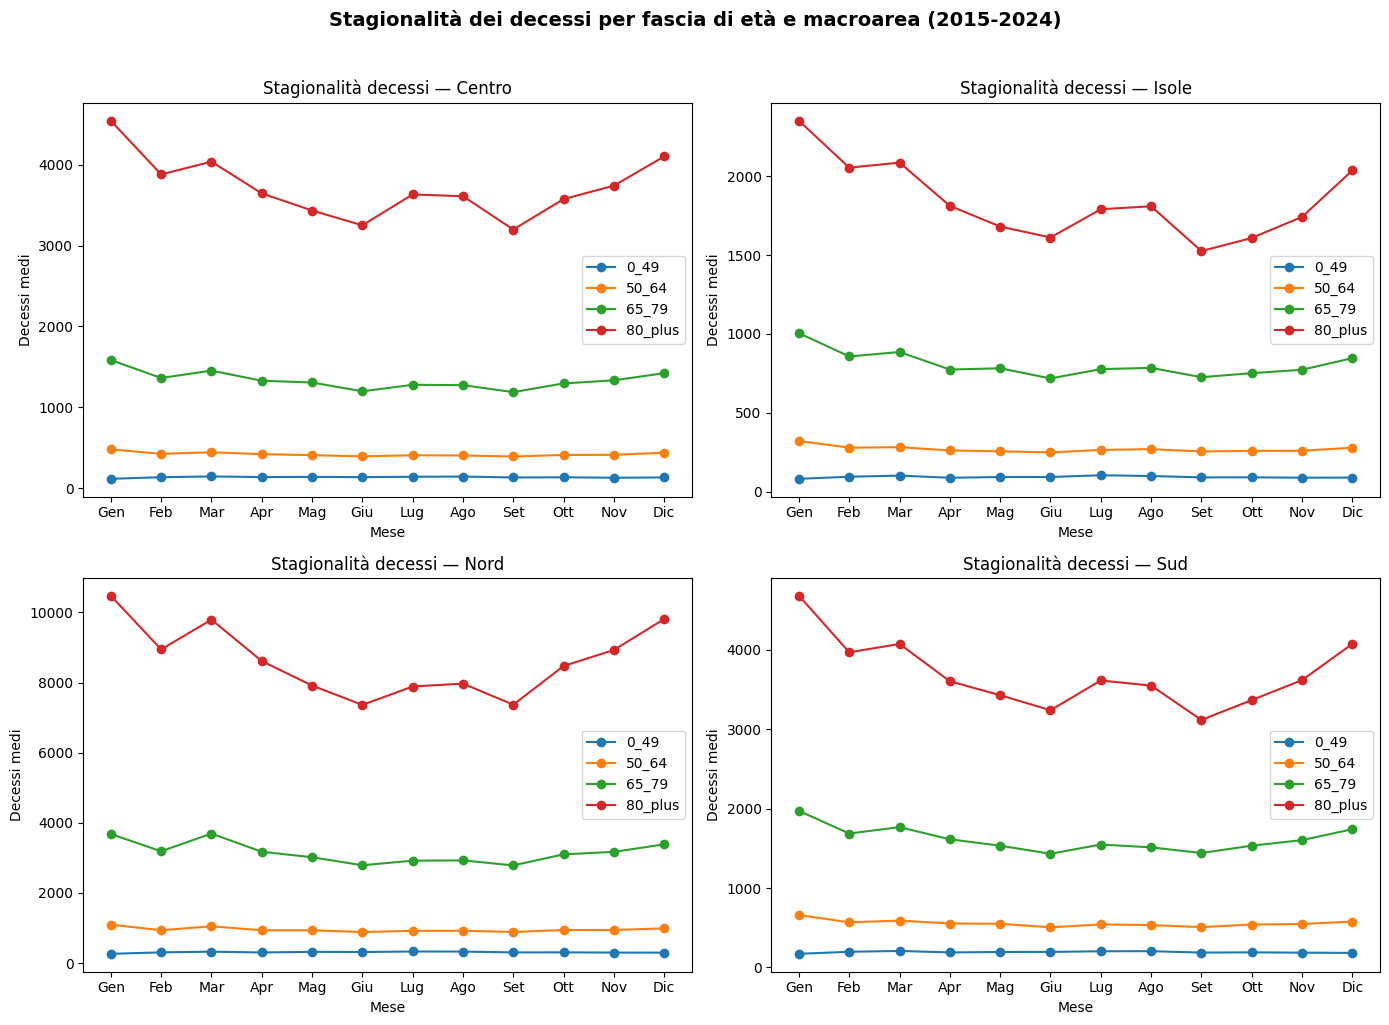

In [96]:
df_plot1 = df_all_long.groupby(['mese_num', 'macroarea', 'fascia_eta'])['decessi'].mean().reset_index()

os.makedirs(r"C:\Users\maria\Desktop\portfolio_mortalità\outputs\charts", exist_ok=True)

macroaree_list = df_plot1['macroarea'].unique()
fasce = df_plot1['fascia_eta'].unique()
mesi_nomi = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu',
             'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, macroarea in enumerate(macroaree_list):
    ax = axes[i]
    df_macro = df_plot1[df_plot1['macroarea'] == macroarea]
    
    for fascia in fasce:
        df_fascia = df_macro[df_macro['fascia_eta'] == fascia].sort_values('mese_num')
        ax.plot(df_fascia['mese_num'], df_fascia['decessi'], marker='o', label=fascia)
    
    ax.set_title(f"Stagionalità decessi — {macroarea.capitalize()}")
    ax.set_xlabel("Mese")
    ax.set_ylabel("Decessi medi")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(mesi_nomi)
    ax.legend()

plt.suptitle("Stagionalità dei decessi per fascia di età e macroarea (2015-2024)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\maria\Desktop\portfolio_mortalità\outputs\charts\grafico1_stagionalita.png", 
            bbox_inches='tight', dpi=150)
plt.show()

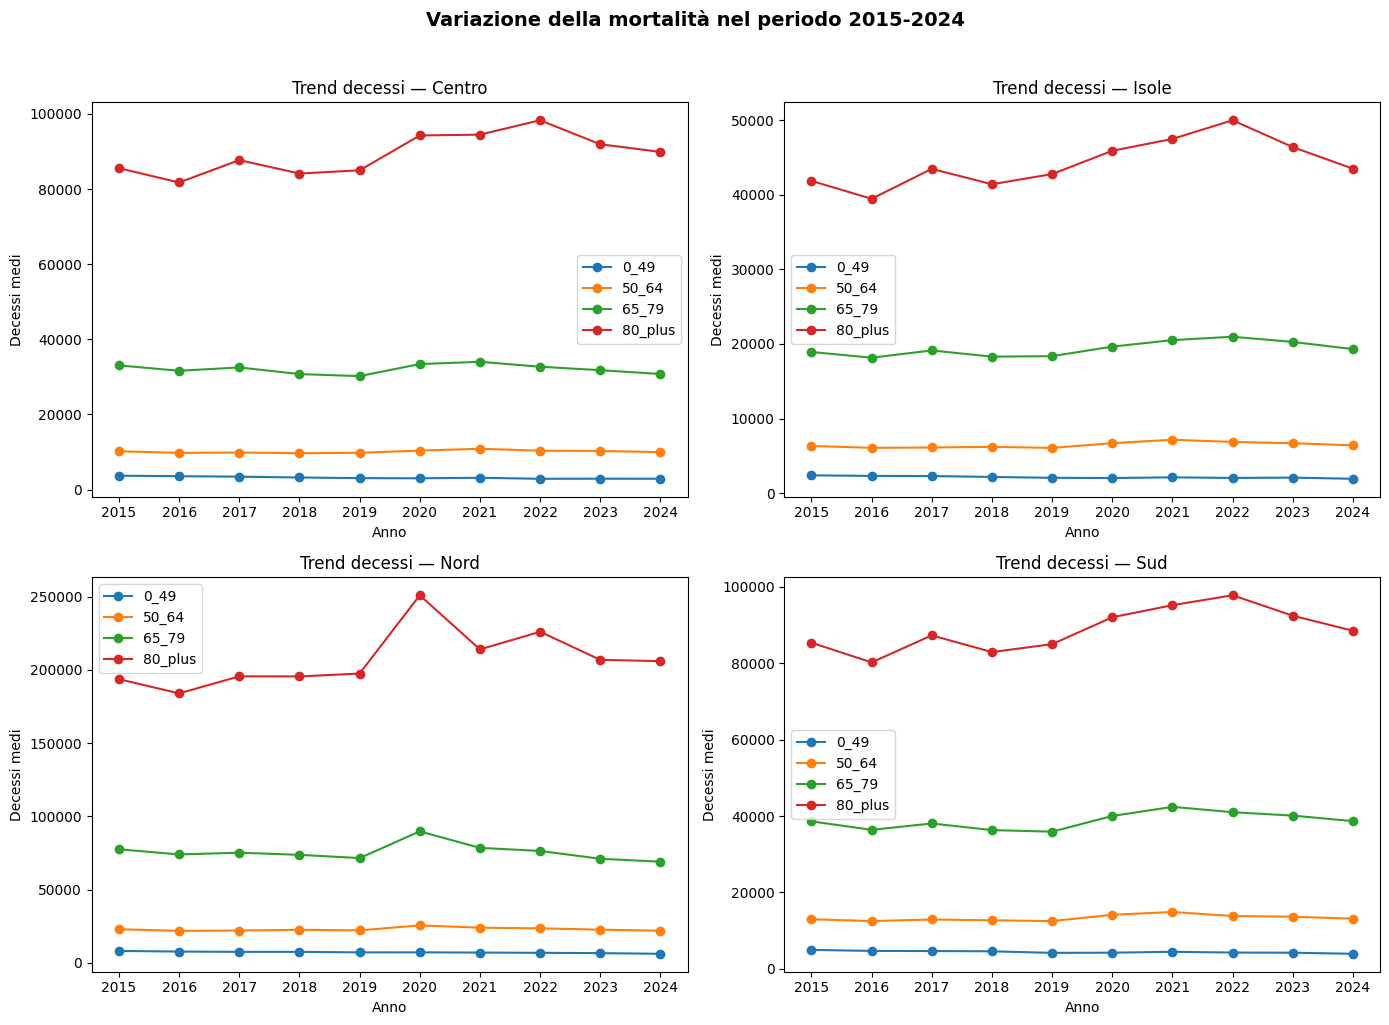

In [97]:
df_plot2 = df_all_long.groupby(['anno', 'macroarea', 'fascia_eta'])['decessi'].sum().reset_index()

macroaree_list = df_plot1['macroarea'].unique()
fasce = df_plot1['fascia_eta'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, macroarea in enumerate(macroaree_list):
    ax = axes[i]
    df_macro = df_plot2[df_plot2['macroarea'] == macroarea]
    
    for fascia in fasce:
        df_fascia = df_macro[df_macro['fascia_eta'] == fascia].sort_values('anno')
        ax.plot(df_fascia['anno'], df_fascia['decessi'], marker='o', label=fascia)
    
    ax.set_title(f"Trend decessi — {macroarea.capitalize()}")
    ax.set_xlabel("Anno")
    ax.set_ylabel("Decessi medi")
    ax.set_xticks(range(2015, 2025))
    ax.legend()

plt.suptitle("Variazione della mortalità nel periodo 2015-2024", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\maria\Desktop\portfolio_mortalità\outputs\charts\grafico2_trend_annuale.png", 
            bbox_inches='tight', dpi=150)
plt.show()

In [98]:
conn = sqlite3.connect(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_completo.db")

df_risultati_mensili.to_csv(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\risultati_mensili.csv", index=False, encoding="utf-8-sig", decimal=',')
df_risultati_trend.to_csv(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\risultati_trend.csv", index=False, encoding="utf-8-sig", decimal=',')

pythonconn = sqlite3.connect(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_completo.db")
df_all_long.to_csv(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_long.csv", index=False, encoding="utf-8-sig", decimal=',')
df_all_long.to_sql("decessi_long", conn, if_exists="replace", index=False)

conn.close()

print("Esportazione completata")

Esportazione completata


In [1]:
conn = sqlite3.connect(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\decessi_macroaree_completo.db")

df_all = pd.read_sql("SELECT * FROM decessi_macroaree", conn)
conn.close()

df_all_long = pd.melt(
    df_all,
    id_vars=["macroarea", "anno"],
    value_vars=df_all.columns[2:].to_list(),
    var_name="variabile",
    value_name="decessi"
)

df_all_long['sesso'] = df_all_long['variabile'].str.split('_', n=1).str[0]
df_all_long['resto'] = df_all_long['variabile'].str.split('_', n=1).str[1]
df_all_long['mese'] = df_all_long['resto'].str.split('_').str[-1]
df_all_long['fascia_eta'] = df_all_long['resto'].str.replace(r'_[^_]+$', '', regex=True)
df_all_long = df_all_long.drop(columns=['variabile', 'resto'])

df_plot2 = df_all_long.groupby(['anno', 'macroarea', 'fascia_eta'])['decessi'].sum().reset_index()

df_plot2.to_csv(r"C:\Users\maria\Desktop\portfolio_mortalità\data\processed\trend_annuale.csv", index=False, encoding="utf-8-sig", decimal=',')

print("Esportato")
print(df_plot2.head())

Esportato
   anno macroarea fascia_eta  decessi
0  2015    centro       0_49     3698
1  2015    centro      50_64    10201
2  2015    centro      65_79    33057
3  2015    centro    80_plus    85542
4  2015     isole       0_49     2382
